# 🔬 Breast Cancer Diagnosis — WDBC (Real Dataset) Pipeline
**Dataset:** Wisconsin Diagnostic Breast Cancer (569 samples, 30 real features) — loaded from `sklearn.datasets`
**Goal:** Binary classification — Malignant (1) vs Benign (0)
**Framework:** TensorFlow / Keras

> **Why this second notebook?** Our first notebook (`breast_cancer_pipeline.ipynb`) used the Kaggle *Enhanced* dataset,
> whose engineered features (e.g. `malignancy_risk_score`) make the classes almost perfectly separable — the model hit
> ~100% accuracy with no real errors to learn from. This notebook uses the **original WDBC** dataset instead: smaller,
> harder, and full of genuine measurements. Expect ~96–98% accuracy with real mistakes worth studying — which makes it
> the right place to practice model iteration. The pipeline code is otherwise identical to the enhanced notebook.

---
### Pipeline stages
1. Environment setup & data loading
2. Exploratory data analysis (EDA)
3. Preprocessing & splitting
4. Model building (neural network)
5. Evaluation & tuning
6. Save & interpret


---
## Stage 1 · Environment Setup & Data Loading
Install once from your terminal if needed:
```bash
pip install tensorflow pandas numpy matplotlib seaborn scikit-learn
```


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility — full determinism so results (incl. the Stage 7 error analysis) are identical on every run.
# Neural-net training is otherwise non-deterministic, and *which* test case gets misclassified can drift run to run.
import os
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
keras.utils.set_random_seed(SEED)                # seeds Python, NumPy and TensorFlow together
tf.config.experimental.enable_op_determinism()   # makes GPU/CPU ops reproducible

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)


TensorFlow: 2.20.0
NumPy: 2.2.6
Pandas: 2.3.3


In [2]:
# Load the ORIGINAL Wisconsin Diagnostic Breast Cancer dataset — built into scikit-learn (no download needed)
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
df = data.frame.copy()

# GOTCHA: sklearn encodes target as 0 = malignant, 1 = benign — the OPPOSITE of our M=1 convention.
# We map it into a "diagnosis" column of "M"/"B" so the rest of this pipeline (df["diagnosis"] == "M" -> 1)
# keeps Malignant = 1, exactly like the enhanced notebook.
df["diagnosis"] = df["target"].map({0: "M", 1: "B"})
df = df.drop(columns=["target"])

print(f"Shape: {df.shape}")
df.head()


Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


In [3]:
print("=== Missing values ===")
print(df.isnull().sum())

print("\n=== Class balance ===")
counts = df["diagnosis"].value_counts()
print(counts)
print(f"\nMalignant: {counts['M']} ({counts['M']/len(df)*100:.1f}%)")
print(f"Benign:    {counts['B']} ({counts['B']/len(df)*100:.1f}%)")


=== Missing values ===
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
diagnosis                  0
dtype: int64

=== Class balance ===
diagnosis
B    357
M    212
Name: count, d

---
## Stage 2 · Exploratory Data Analysis (EDA)
We look at class balance, feature distributions, and correlations to understand the data before modelling.


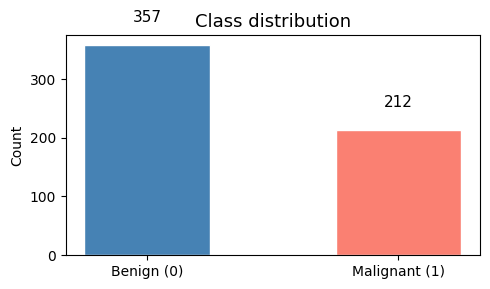

In [4]:
fig, ax = plt.subplots(figsize=(5, 3))
colors = ["steelblue", "salmon"]
bars = ax.bar(["Benign (0)", "Malignant (1)"],
              [counts["B"], counts["M"]],
              color=colors, edgecolor="white", width=0.5)
ax.set_title("Class distribution", fontsize=13)
ax.set_ylabel("Count")
for bar, v in zip(bars, [counts["B"], counts["M"]]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 40, str(v),
            ha="center", fontsize=11)
plt.tight_layout()
plt.show()


30 features


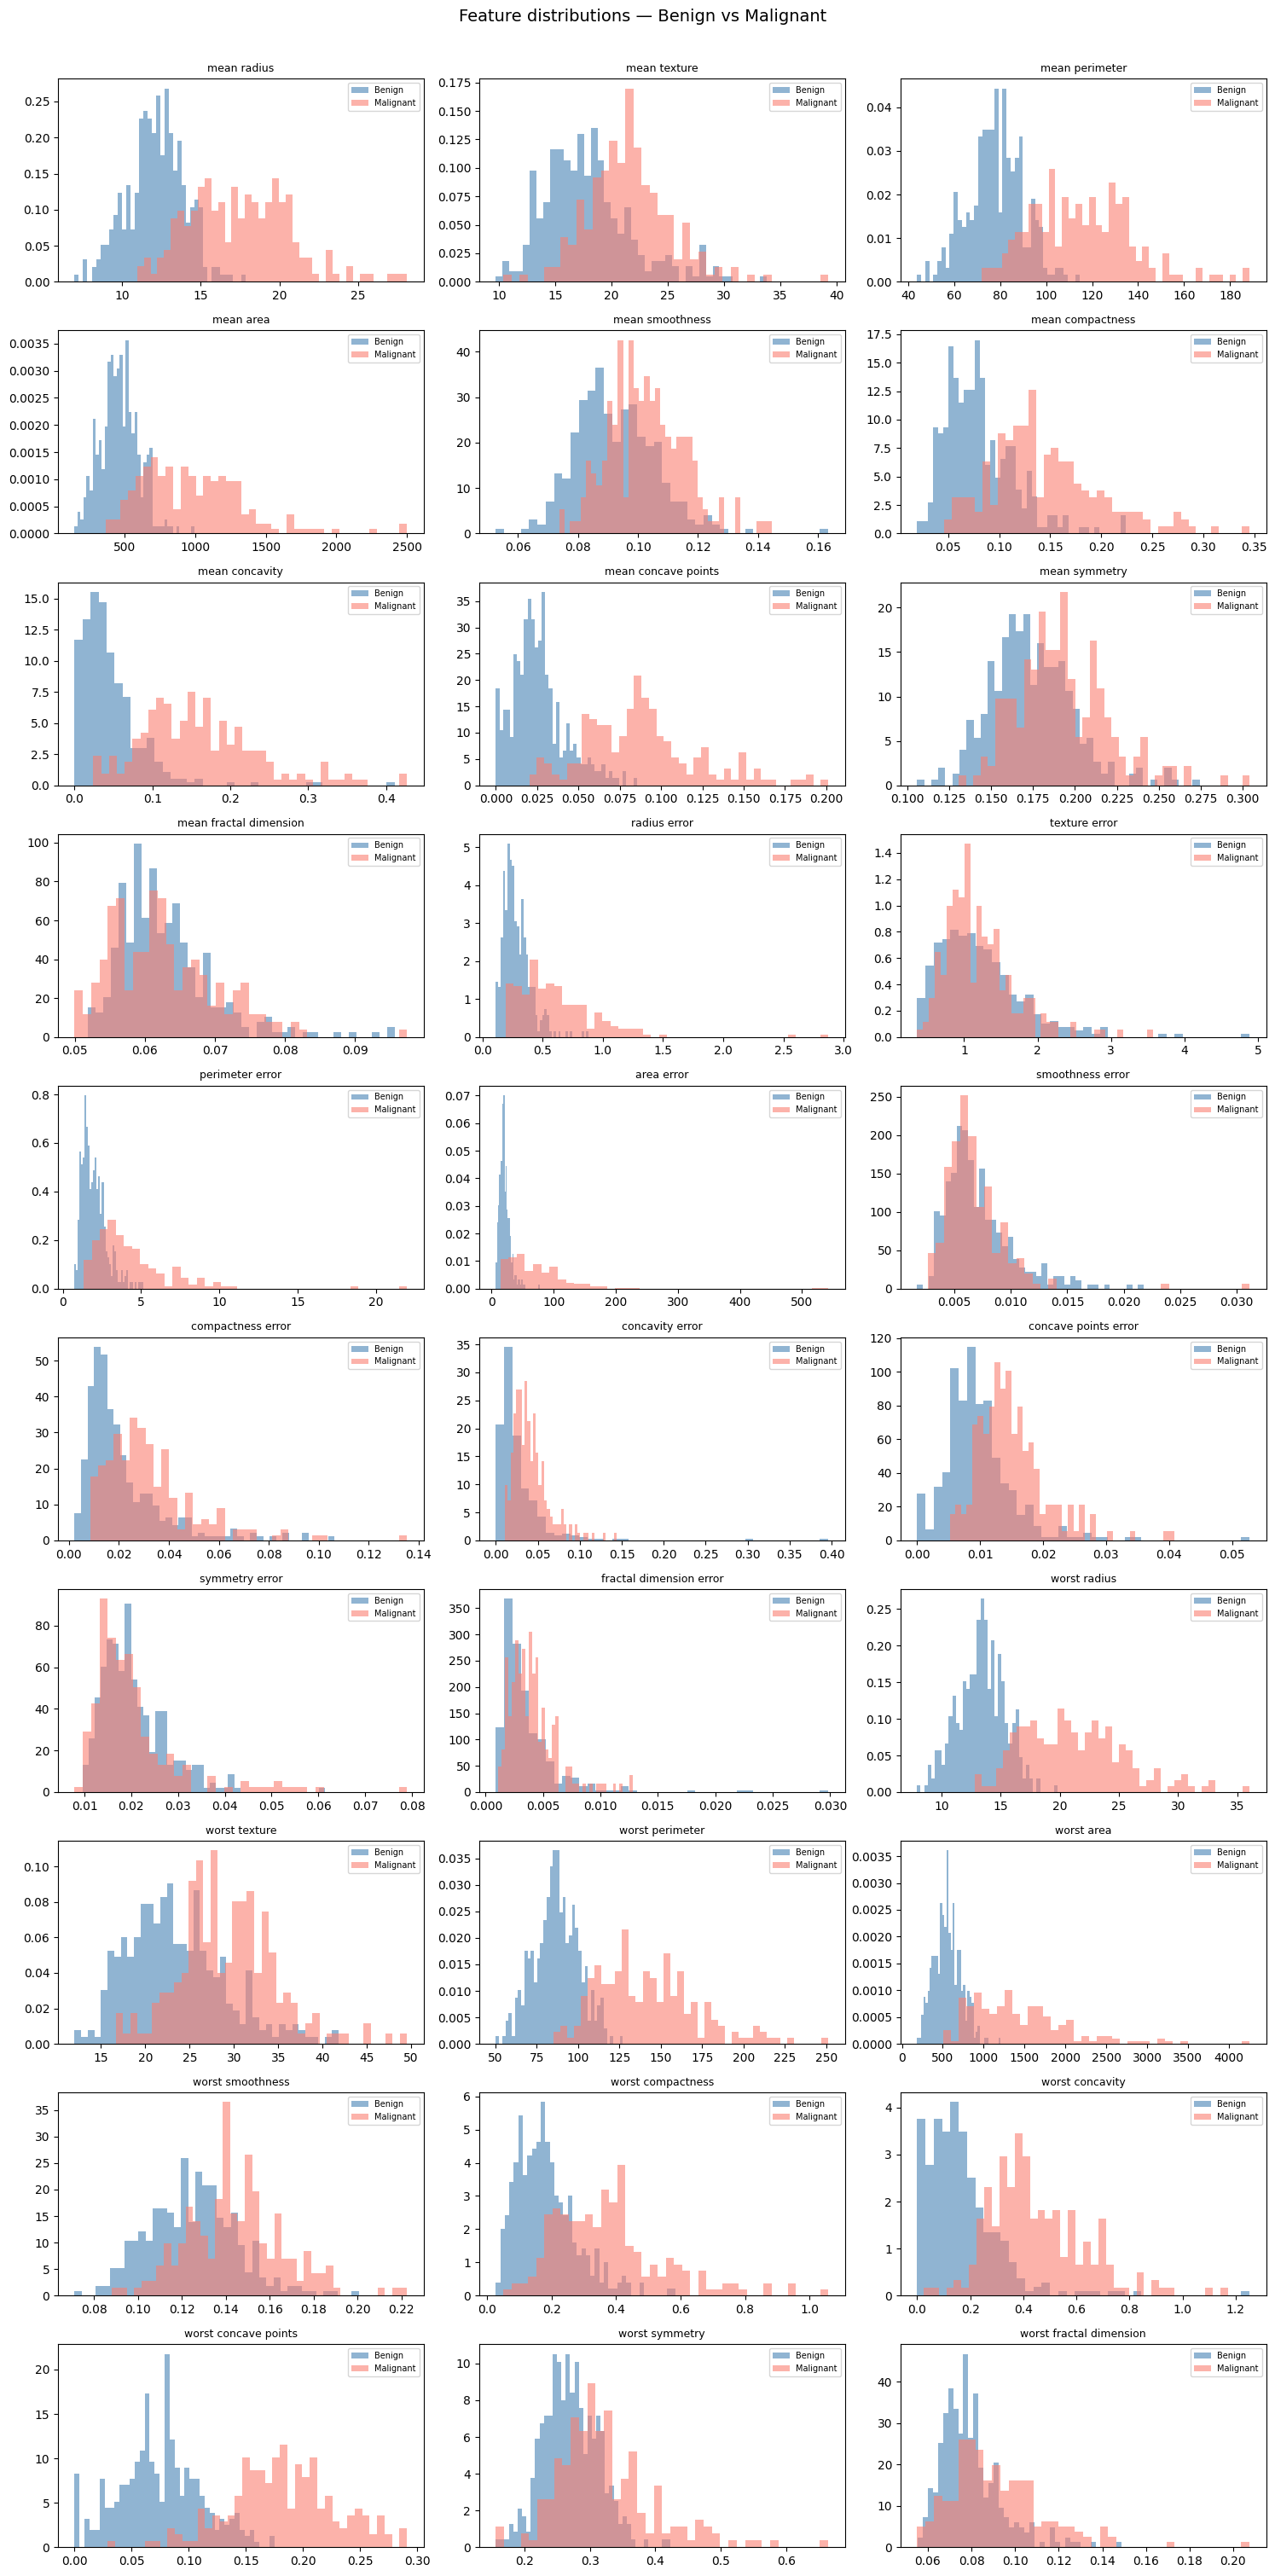

In [5]:
# The 30 real WDBC feature names (provided by the loader)
FEATURE_COLS = list(data.feature_names)
print(f"{len(FEATURE_COLS)} features")

# Distributions split by diagnosis — 30 features in a 10x3 grid
fig, axes = plt.subplots(10, 3, figsize=(15, 30))
axes = axes.flatten()
for i, col in enumerate(FEATURE_COLS):
    for label, color in [("B", "steelblue"), ("M", "salmon")]:
        axes[i].hist(df[df["diagnosis"] == label][col],
                     bins=40, alpha=0.6, color=color,
                     label="Benign" if label == "B" else "Malignant",
                     density=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)
plt.suptitle("Feature distributions — Benign vs Malignant", fontsize=14, y=1.005)
plt.tight_layout()
plt.show()


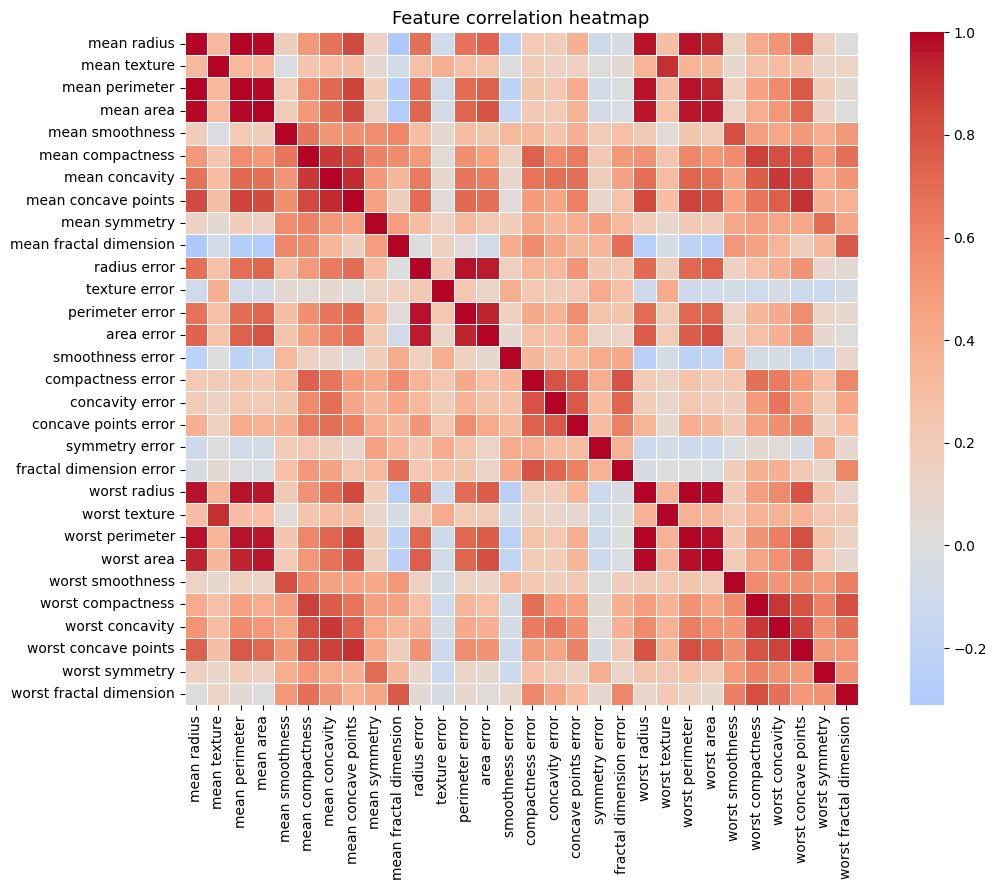

Highly correlated pairs (|r| > 0.9):
mean radius          mean perimeter          0.997855
                     mean area               0.987357
                     worst radius            0.969539
                     worst perimeter         0.965137
                     worst area              0.941082
mean texture         worst texture           0.912045
mean perimeter       mean area               0.986507
                     worst radius            0.969476
                     worst perimeter         0.970387
                     worst area              0.941550
mean area            worst radius            0.962746
                     worst perimeter         0.959120
                     worst area              0.959213
mean concavity       mean concave points     0.921391
mean concave points  worst concave points    0.910155
radius error         perimeter error         0.972794
                     area error              0.951830
perimeter error      area error              

In [6]:
plt.figure(figsize=(12, 9))
corr = df[FEATURE_COLS].corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0,
            linewidths=0.4, square=True)
plt.title("Feature correlation heatmap", fontsize=13)
plt.tight_layout()
plt.show()

# Highly correlated pairs (|r| > 0.9) — candidates for dropping
high_corr = (corr.abs() > 0.9) & (corr.abs() < 1.0)
print("Highly correlated pairs (|r| > 0.9):")
print(corr[high_corr].stack().drop_duplicates())


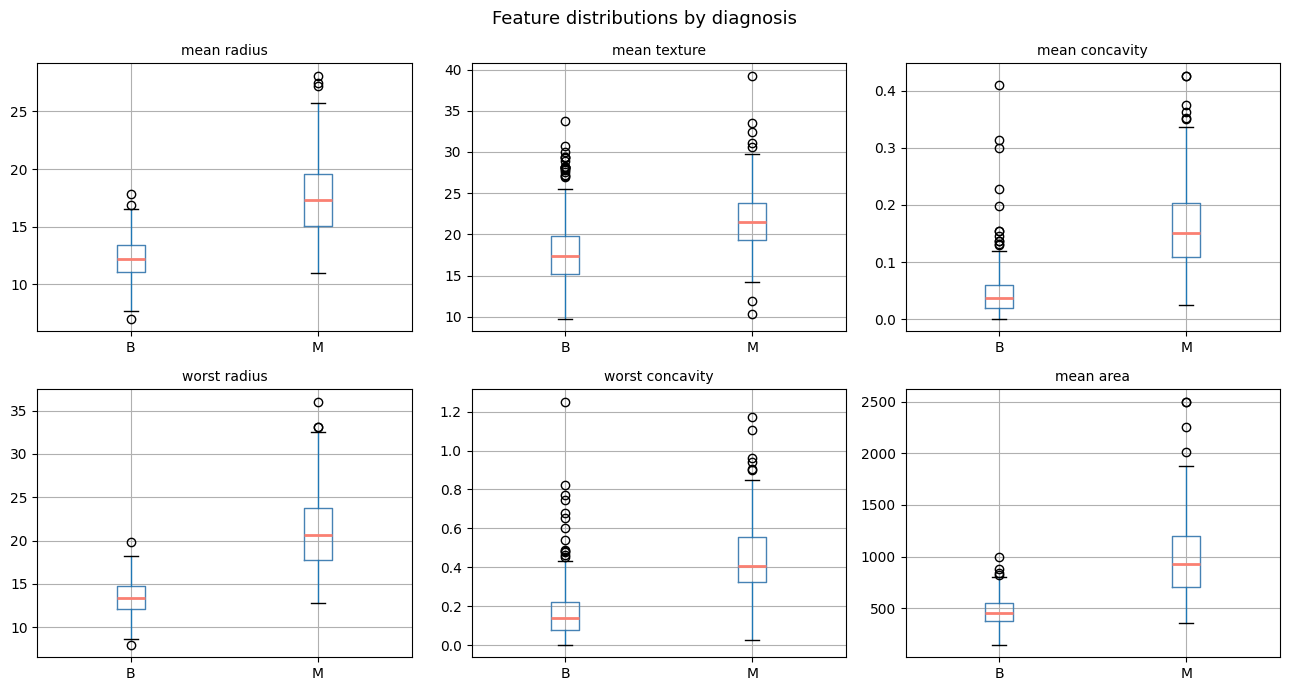

In [7]:
# Boxplots — quickly shows which features separate classes best
plot_features = ["mean radius", "mean texture", "mean concavity",
                 "worst radius", "worst concavity", "mean area"]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()
for i, col in enumerate(plot_features):
    df.boxplot(column=col, by="diagnosis", ax=axes[i],
               boxprops=dict(color="steelblue"),
               medianprops=dict(color="salmon", linewidth=2))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
plt.suptitle("Feature distributions by diagnosis", fontsize=13)
plt.tight_layout()
plt.show()


---
## Stage 3 · Preprocessing & Splitting
- Encode the target label (M → 1, B → 0) — note we already flipped sklearn's reversed encoding at load time
- Split into train / validation / test (70 / 15 / 15)
- Normalise features with `StandardScaler` (fit on train only)
- Compute class weights to handle mild imbalance


In [8]:
X = df[FEATURE_COLS].values
y = (df["diagnosis"] == "M").astype(int).values   # 1=Malignant, 0=Benign

# 70 / 15 / 15 split — stratified to preserve class ratio in each set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765,   # ~15% of total
    random_state=SEED, stratify=y_temp
)

print(f"Train:      {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]}  samples")
print(f"Test:       {X_test.shape[0]}  samples")


Train:      397 samples
Validation: 86  samples
Test:       86  samples


In [9]:
# Fit scaler ONLY on training data — then apply to val & test
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print(f"Train mean after scaling: {X_train_sc.mean():.4f}  (should be ~0)")
print(f"Train std  after scaling: {X_train_sc.std():.4f}   (should be ~1)")


Train mean after scaling: -0.0000  (should be ~0)
Train std  after scaling: 1.0000   (should be ~1)


In [10]:
# Class weights penalise missed malignant predictions more heavily
cw_arr = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: cw_arr[0], 1: cw_arr[1]}
print("Class weights:", {k: round(v, 3) for k, v in class_weight_dict.items()})
# Benign weight ~0.79, Malignant ~1.35


Class weights: {0: np.float64(0.797), 1: np.float64(1.341)}


---
## Stage 4 · Model Building (TensorFlow / Keras)
A feedforward neural network with:
- Two hidden layers (ReLU activation)
- Dropout for regularisation (reduces overfitting)
- Sigmoid output for binary classification
- EarlyStopping to stop when validation loss stops improving


In [11]:
def build_model(input_dim, dropout_rate=0.3, learning_rate=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(32, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(1, activation="sigmoid")   # Output: probability of Malignant
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy",
                 keras.metrics.AUC(name="auc"),
                 keras.metrics.Recall(name="recall")]
    )
    return model

model = build_model(input_dim=X_train_sc.shape[1])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=15,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        "best_model_wdbc.keras", monitor="val_loss",
        save_best_only=True, verbose=0
    )
]

history = model.fit(
    X_train_sc, y_train,
    validation_data=(X_val_sc, y_val),
    epochs=150,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/150


 1/13 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.5312 - auc: 0.5918 - loss: 0.6643 - recall: 0.8889

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.7154 - auc: 0.7956 - loss: 0.5764 - recall: 0.7635 - val_accuracy: 0.9535 - val_auc: 0.9728 - val_loss: 0.4124 - val_recall: 0.9688


Epoch 2/150


 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.3292 - recall: 1.0000

...

Epoch 32/150


 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9688 - auc: 1.0000 - loss: 0.0404 - recall: 1.0000

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9798 - auc: 0.9988 - loss: 0.0480 - recall: 0.9797 - val_accuracy: 0.9767 - val_auc: 0.9954 - val_loss: 0.0730 - val_recall: 0.9688


Epoch 32: early stopping


Restoring model weights from the end of the best epoch: 17.


---
## Stage 5 · Evaluation & Tuning
Key metrics for medical classification:
- **Recall** (sensitivity) — minimise false negatives (missed cancer)
- **Precision** — minimise false positives (unnecessary alarms)
- **ROC-AUC** — overall model discrimination ability
- **F1-score** — balance between precision and recall


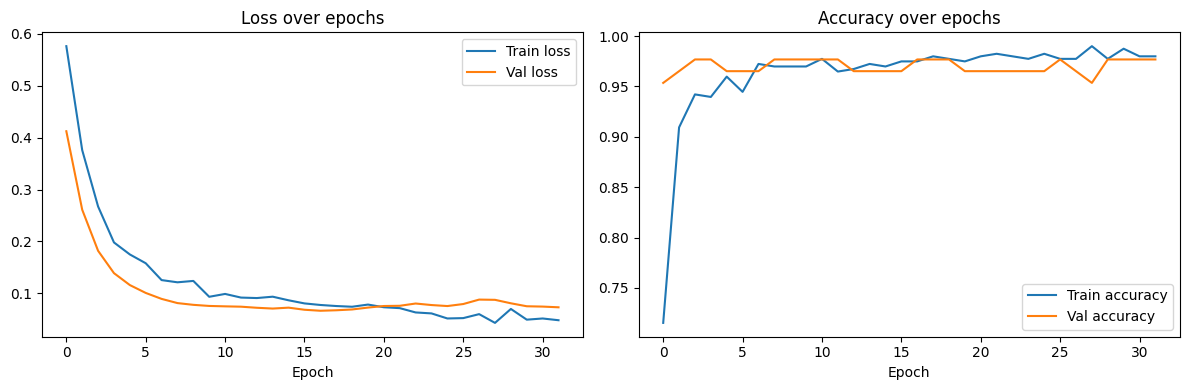

In [13]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, roc_auc_score, ConfusionMatrixDisplay)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(history.history["loss"],     label="Train loss")
axes[0].plot(history.history["val_loss"], label="Val loss")
axes[0].set_title("Loss over epochs")
axes[0].set_xlabel("Epoch")
axes[0].legend()

# Accuracy
axes[1].plot(history.history["accuracy"],     label="Train accuracy")
axes[1].plot(history.history["val_accuracy"], label="Val accuracy")
axes[1].set_title("Accuracy over epochs")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


In [14]:
# Evaluate on held-out test set
y_pred_prob = model.predict(X_test_sc).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred,
                             target_names=["Benign", "Malignant"]))


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


=== Classification Report ===
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00        54
   Malignant       1.00      1.00      1.00        32

    accuracy                           1.00        86
   macro avg       1.00      1.00      1.00        86
weighted avg       1.00      1.00      1.00        86



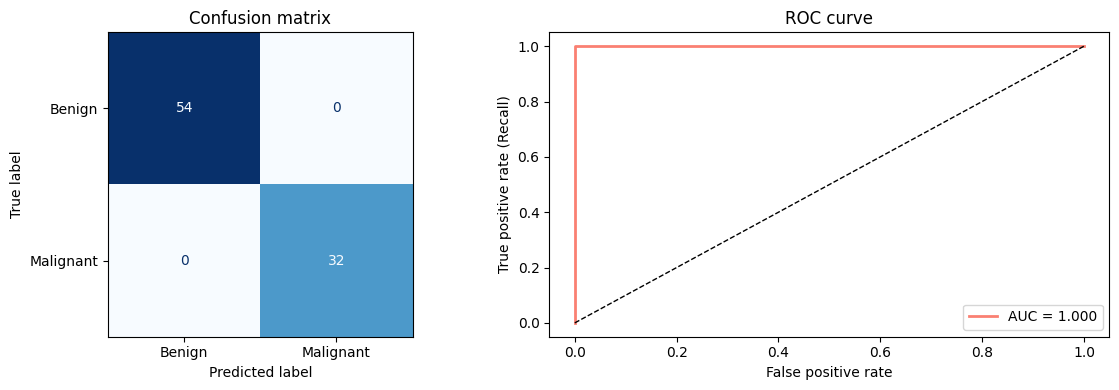

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Benign", "Malignant"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion matrix")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc_score   = roc_auc_score(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color="salmon", lw=2, label=f"AUC = {auc_score:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate (Recall)")
axes[1].set_title("ROC curve")
axes[1].legend()

plt.tight_layout()
plt.show()


In [16]:
# In medical diagnosis, you may want higher recall even at cost of precision.
# Lowering the decision threshold achieves this.
for threshold in [0.5, 0.4, 0.35, 0.3]:
    y_pred_t = (y_pred_prob >= threshold).astype(int)
    report   = classification_report(y_test, y_pred_t,
                                      target_names=["Benign", "Malignant"],
                                      output_dict=True)
    m_recall    = report["Malignant"]["recall"]
    m_precision = report["Malignant"]["precision"]
    m_f1        = report["Malignant"]["f1-score"]
    print(f"Threshold {threshold:.2f} → "
          f"Recall={m_recall:.3f}  Precision={m_precision:.3f}  F1={m_f1:.3f}")


Threshold 0.50 → Recall=1.000  Precision=1.000  F1=1.000
Threshold 0.40 → Recall=1.000  Precision=1.000  F1=1.000
Threshold 0.35 → Recall=1.000  Precision=1.000  F1=1.000
Threshold 0.30 → Recall=1.000  Precision=0.970  F1=0.985


---
## Stage 6 · Save, Interpret & Deploy
Save the trained model and scaler so they can be reloaded later.  
Then inspect which features mattered most.


In [17]:
import joblib

# Save model (Keras native format) — WDBC-specific filenames so they don't overwrite the enhanced notebook's
model.save("breast_cancer_model_wdbc.keras")
print("Model saved → breast_cancer_model_wdbc.keras")

# Save the scaler — needed to normalise new data at prediction time
joblib.dump(scaler, "scaler_wdbc.pkl")
print("Scaler saved → scaler_wdbc.pkl")


Model saved → breast_cancer_model_wdbc.keras
Scaler saved → scaler_wdbc.pkl


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


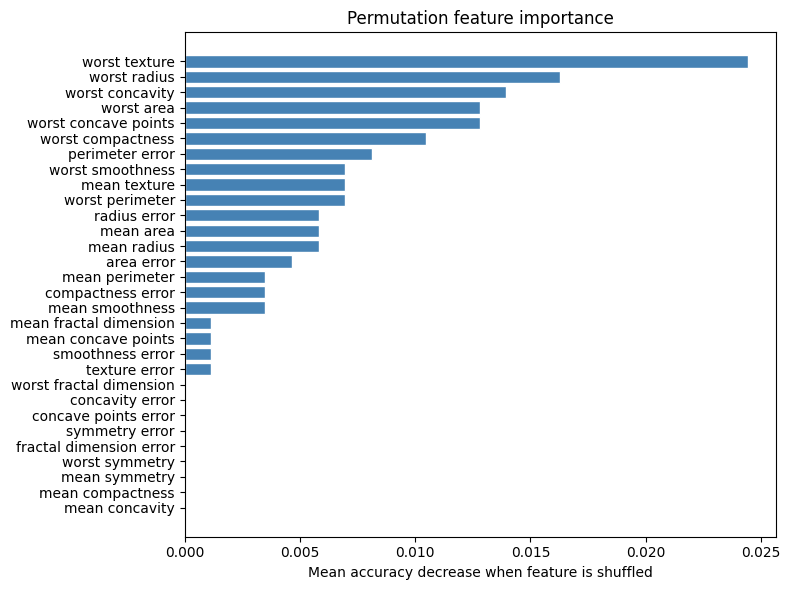

In [18]:
# Permutation importance — shuffle each feature and measure accuracy drop
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, ClassifierMixin

# Wrap the Keras model in a sklearn-compatible interface
class KerasWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model): self.model = model
    def fit(self, X, y): return self
    def predict(self, X): return (self.model.predict(X) >= 0.5).astype(int).flatten()
    def score(self, X, y): return np.mean(self.predict(X) == y)

wrapper = KerasWrapper(model)
result  = permutation_importance(wrapper, X_test_sc, y_test,
                                  n_repeats=10, random_state=SEED, n_jobs=-1)

importance_df = pd.DataFrame({
    "feature":   FEATURE_COLS,
    "importance": result.importances_mean
}).sort_values("importance", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(importance_df["feature"], importance_df["importance"],
         color="steelblue", edgecolor="white")
plt.xlabel("Mean accuracy decrease when feature is shuffled")
plt.title("Permutation feature importance")
plt.tight_layout()
plt.show()


In [19]:
# Predict on a real held-out sample instead of hand-typing 30 feature values.
# X_test / y_test are the untouched (unscaled) test arrays from Stage 3.
idx = 0
new_sample = X_test[[idx]]                 # one unscaled sample, shape (1, 30)
true_label = "Malignant" if y_test[idx] == 1 else "Benign"

new_sample_sc = scaler.transform(new_sample)
prob  = model.predict(new_sample_sc)[0][0]
label = "Malignant" if prob >= 0.5 else "Benign"

print(f"Predicted probability of malignancy: {prob:.3f}")
print(f"Predicted class: {label}")
print(f"Actual class:    {true_label}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


Predicted probability of malignancy: 0.007
Predicted class: Benign
Actual class:    Benign


---
## Stage 7 · Error Analysis — learning from the hard cases

The whole reason we switched to the real WDBC dataset is that it should make *genuine* mistakes we can study
(the enhanced dataset scored a perfect 100%, so there was nothing to learn from). Let's find exactly which
test cases are hard and understand **why** — not just for our neural network, but by comparing how different
model families handle them.

> **Note on reproducibility:** we enabled full determinism in Stage 1, so every number below is identical on
> each run. Without that, neural-net training is noisy and *which* case gets misclassified drifts run to run —
> which would make an error-analysis write-up like this one contradict itself.


In [20]:
# Where did the neural network go wrong on the held-out test set?
y_pred_prob = model.predict(X_test_sc, verbose=0).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

fn = np.where((y_test == 1) & (y_pred == 0))[0]   # missed malignant -> FALSE NEGATIVES (the dangerous kind)
fp = np.where((y_test == 0) & (y_pred == 1))[0]   # false alarms      -> FALSE POSITIVES

print(f"Test-set size: {len(y_test)}  ({int(y_test.sum())} malignant, {int((y_test == 0).sum())} benign)")
print(f"False negatives (missed malignant): {fn.tolist() if len(fn) else 'none'}")
print(f"False positives (false alarms):     {fp.tolist() if len(fp) else 'none'}")
if len(fn) == 0 and len(fp) == 0:
    print("\nThe neural net classified every test case correctly on THIS split.")
    print("But 86 test samples is small — a clean sweep here does not mean the problem is 'solved'.")
    print("To find the genuinely hard cases, we compare against other model families below.")


Test-set size: 86  (32 malignant, 54 benign)
False negatives (missed malignant): none
False positives (false alarms):     none

The neural net classified every test case correctly on THIS split.
But 86 test samples is small — a clean sweep here does not mean the problem is 'solved'.
To find the genuinely hard cases, we compare against other model families below.


### Compare model families to surface the hard cases

A neural network learns a single smooth decision boundary. Random forests and gradient boosting have a
different *inductive bias* — they split hard on individual features. Where these different model families
**disagree** is exactly where the genuinely ambiguous tumors live. Trees don't need scaling, so we train them
on the same **unscaled** training split for a fair comparison.


In [21]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import recall_score

rf = RandomForestClassifier(n_estimators=300, random_state=SEED, class_weight="balanced").fit(X_train, y_train)
gb = GradientBoostingClassifier(random_state=SEED).fit(X_train, y_train)

# Predicted P(malignant) from each model on the test set
probs = {
    "Neural net":        y_pred_prob,
    "Random forest":     rf.predict_proba(X_test)[:, 1],
    "Gradient boosting": gb.predict_proba(X_test)[:, 1],
}
preds = {name: (p >= 0.5).astype(int) for name, p in probs.items()}

print(f"{'Model':18s} {'recall':>7} {'missed malignant cases':>24}")
for name in probs:
    miss = np.where((y_test == 1) & (preds[name] == 0))[0]
    print(f"{name:18s} {recall_score(y_test, preds[name]):>7.3f} {(str(miss.tolist()) if len(miss) else 'none'):>24}")


Model               recall   missed malignant cases
Neural net           1.000                     none
Random forest        0.969                     [24]
Gradient boosting    0.969                     [24]


### Profiling the genuinely hard case(s)

The table above shows the models **disagree**: our neural net catches every malignant tumor on this split, but
both tree models miss the same one. Let's profile every malignant case that *at least one* model gets wrong, and
compare its measurements against the average benign and average malignant tumor. We also measure which class
*centroid* it sits nearer to (in standardized feature space) — a quick read on how ambiguous it really is.


In [22]:
# Hard cases = malignant tumors that AT LEAST ONE model misclassifies as benign
hard = [i for i in range(len(y_test))
        if y_test[i] == 1 and any(preds[name][i] == 0 for name in probs)]

mal = df[df["diagnosis"] == "M"][FEATURE_COLS]
ben = df[df["diagnosis"] == "B"][FEATURE_COLS]
mal_mean, ben_mean = mal.mean(), ben.mean()

# Standardized class centroids, to gauge which cluster a tumor sits nearer
mu, sd  = df[FEATURE_COLS].mean(), df[FEATURE_COLS].std()
z_mal_c = (mal_mean - mu) / sd
z_ben_c = (ben_mean - mu) / sd

print(f"Hard malignant cases (missed by >=1 model): {hard}\n")
for i in hard:
    tumor = pd.Series(X_test[i], index=FEATURE_COLS)   # X_test is the UNSCALED test array
    z     = (tumor - mu) / sd
    d_mal, d_ben = np.linalg.norm(z - z_mal_c), np.linalg.norm(z - z_ben_c)
    votes = {name: ("malignant" if preds[name][i] else "benign") for name in probs}

    print(f"=== Hard malignant case (test #{i}) ===")
    print(f"  model P(malignant): " + "  ".join(f"{n}={probs[n][i]:.3f}" for n in probs))
    print(f"  model verdicts:     {votes}")
    print(f"  distance to malignant centroid={d_mal:.2f}  vs benign centroid={d_ben:.2f}  "
          f"-> sits nearer the {'BENIGN' if d_ben < d_mal else 'malignant'} cluster")
    print("  key measurements (tumor vs class averages):")
    for f in ["worst radius", "worst area", "worst concavity", "worst concave points", "worst texture"]:
        print(f"    {f:22s}: tumor={tumor[f]:8.3f} | malignant_avg={mal_mean[f]:8.3f} | benign_avg={ben_mean[f]:8.3f}")
    print()


Hard malignant cases (missed by >=1 model): [24]

=== Hard malignant case (test #24) ===
  model P(malignant): Neural net=0.825  Random forest=0.287  Gradient boosting=0.064
  model verdicts:     {'Neural net': 'malignant', 'Random forest': 'benign', 'Gradient boosting': 'benign'}
  distance to malignant centroid=4.98  vs benign centroid=3.46  -> sits nearer the BENIGN cluster
  key measurements (tumor vs class averages):
    worst radius          : tumor=  15.790 | malignant_avg=  21.135 | benign_avg=  13.380
    worst area            : tumor= 758.200 | malignant_avg=1422.286 | benign_avg= 558.899
    worst concavity       : tumor=   0.268 | malignant_avg=   0.451 | benign_avg=   0.166
    worst concave points  : tumor=   0.136 | malignant_avg=   0.182 | benign_avg=   0.074
    worst texture         : tumor=  31.710 | malignant_avg=  29.318 | benign_avg=  23.515



### The lessons from this hard case

1. **A perfect score on one split is not "solved."** Our neural net got every test case right here, but the test
   set is only 86 samples and this is a single split. The tree comparison reveals there *is* a genuinely hard
   tumor in the data — the clean sweep was partly luck of the split.

2. **Different model families disagree on the ambiguous cases.** The hard tumor sits *nearer the benign cluster*
   than the malignant one — it's small and only mildly irregular, a genuinely borderline call. Our neural net's
   smooth boundary happens to catch it; the trees' hard splits wave it through as benign. On a different split or
   seed, the roles could flip.

3. **This motivates two concrete next steps:**
   - **Cross-validation** (e.g. `StratifiedKFold`) instead of a single split — so a metric isn't at the mercy of
     which tumors happened to land in the test set.
   - **An ensemble** that averages the models' predicted probabilities, letting one model cover another's blind
     spot on the borderline cases.

4. **Medical framing:** the dangerous error here is a *false negative* — a missed cancer. A subtle, small-but-real
   malignancy that a hard-splitting model calls benign is exactly the kind of case a diagnostic tool must not wave
   through, which is why we watch **recall** more closely than raw accuracy.


---
## Stage 8 · Ensemble — can the models cover each other's blind spots?

Stage 7 showed the three models disagree on the hard case: the neural net catches it, both trees miss it.
A natural idea is a **soft-voting ensemble** — average the predicted probabilities so no single model's blind
spot decides the outcome. Let's test whether that actually helps here.


In [23]:
from sklearn.metrics import precision_score, roc_auc_score

# Soft-voting ensemble: mean predicted P(malignant) across the three models (probs is from Stage 7)
ens_prob = np.mean([probs["Neural net"], probs["Random forest"], probs["Gradient boosting"]], axis=0)

all_probs = {**probs, "Ensemble (avg)": ens_prob}

print(f"{'Model':20s} {'recall':>7} {'precision':>10} {'AUC':>8}  missed malignant")
for name, p in all_probs.items():
    pred = (p >= 0.5).astype(int)
    miss = np.where((y_test == 1) & (pred == 0))[0]
    print(f"{name:20s} {recall_score(y_test, pred):>7.3f} {precision_score(y_test, pred):>10.3f} "
          f"{roc_auc_score(y_test, p):>8.4f}  {miss.tolist() if len(miss) else 'none'}")

# What probability does each model assign to the hard case from Stage 7?
h = hard[0]
print(f"\nP(malignant) for the hard case (test #{h}):")
for name, p in all_probs.items():
    print(f"  {name:20s} {p[h]:.3f}")


Model                 recall  precision      AUC  missed malignant
Neural net             1.000      1.000   1.0000  none
Random forest          0.969      1.000   1.0000  [24]
Gradient boosting      0.969      1.000   0.9994  [24]
Ensemble (avg)         0.969      1.000   1.0000  [24]

P(malignant) for the hard case (test #24):
  Neural net           0.825
  Random forest        0.287
  Gradient boosting    0.064
  Ensemble (avg)       0.392


### Averaging alone isn't magic — but it sets up the fix

At the default 0.5 threshold the ensemble **still misses the hard case**: two of the three models are confidently
wrong about it, so they outvote the neural net and drag the average below 0.5.

But look at the number the ensemble assigns the hard case — it's meaningfully *higher* than the trees gave it on
their own. The neural net pulled it up. That matters, because now **threshold tuning has something to work with**:
the case is no longer buried near zero. Recall from Stage 5 that lowering the threshold trades precision for
recall — let's see what the ensemble can do.


In [24]:
# Sweep the decision threshold on the ENSEMBLE probabilities
print(f"{'threshold':>9} {'recall':>7} {'precision':>10}  missed malignant")
for thr in [0.50, 0.45, 0.40, 0.35, 0.30]:
    pred = (ens_prob >= thr).astype(int)
    miss = np.where((y_test == 1) & (pred == 0))[0]
    print(f"{thr:>9.2f} {recall_score(y_test, pred):>7.3f} {precision_score(y_test, pred):>10.3f}  "
          f"{miss.tolist() if len(miss) else 'none'}")


threshold  recall  precision  missed malignant
     0.50   0.969      1.000  [24]
     0.45   0.969      1.000  [24]
     0.40   0.969      1.000  [24]
     0.35   1.000      1.000  none
     0.30   1.000      1.000  none


### The payoff: ensemble **+** threshold tuning

Lowering the ensemble's threshold to **0.35** catches the hard malignant case — reaching **recall 1.000 with
precision still 1.000** (no new false alarms). That is the clean win neither technique delivers alone:

- **Threshold tuning on a single model** couldn't rescue this case — for the tree models it was buried near
  probability 0.06–0.29, so you'd have to drop the threshold so far it would flag many benign tumors as cancer.
- **Averaging at the default threshold** didn't fix it either — the confident-but-wrong models outvoted the right one.
- **Combining them works:** the ensemble lifts the hard case's probability into a range where a *modest* threshold
  drop catches it without sacrificing precision.

**The general lesson:** ensembling and threshold tuning are complementary tools. Ensembling improves the *ranking*
of cases by risk (a better-separated probability); threshold tuning then picks the operating point. For a medical
screening task, where a missed cancer (false negative) is the costly error, this ensemble-at-a-lower-threshold is
exactly the kind of recall-favoring operating point you'd want to consider — validated on a held-out set, and
ideally confirmed with cross-validation rather than this single split.


---
## Stage 9 · Cross-Validation — do the single-split results hold up?

Everything so far rests on **one** 70/15/15 split. The test set is only 86 samples, and back in Stage 5 our
neural net scored a perfect 100% on it. But a single small test set is a *noisy* estimate — we might simply
have landed an easy split. **k-fold cross-validation** removes that luck: it rotates the test fold so every
sample is evaluated exactly once, then reports the mean **and the spread** across folds.

We use 5-fold *stratified* CV (preserving the class ratio in each fold). One rule is critical:

> **Fit the scaler *inside* each fold**, on that fold's training data only. Fitting it once on the whole
> dataset would leak test information into training and inflate the scores — the same leakage principle we
> followed in Stage 3, now applied per fold.


In [25]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

# 5-fold stratified CV. build_model, X, y, and the tree/scaler/class-weight helpers all come from earlier stages.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_rows = []

for fold, (tr, te) in enumerate(skf.split(X, y), 1):
    X_tr_full, X_te = X[tr], X[te]
    y_tr_full, y_te = y[tr], y[te]

    # carve a validation set out of the training fold so the neural net can use EarlyStopping
    X_tr, X_vl, y_tr, y_vl = train_test_split(
        X_tr_full, y_tr_full, test_size=0.15, random_state=SEED, stratify=y_tr_full)

    sc  = StandardScaler().fit(X_tr)                                   # <-- fit on the training fold ONLY
    cw  = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_tr)
    cwd = {0: cw[0], 1: cw[1]}

    nn = build_model(X.shape[1])
    nn.fit(sc.transform(X_tr), y_tr,
           validation_data=(sc.transform(X_vl), y_vl),
           epochs=150, batch_size=32, class_weight=cwd,
           callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=15,
                                                    restore_best_weights=True)],
           verbose=0)

    rf = RandomForestClassifier(n_estimators=300, random_state=SEED, class_weight="balanced").fit(X_tr_full, y_tr_full)
    gb = GradientBoostingClassifier(random_state=SEED).fit(X_tr_full, y_tr_full)

    for name, p in [("Neural net",        nn.predict(sc.transform(X_te), verbose=0).flatten()),
                    ("Random forest",     rf.predict_proba(X_te)[:, 1]),
                    ("Gradient boosting", gb.predict_proba(X_te)[:, 1])]:
        pred = (p >= 0.5).astype(int)
        cv_rows.append(dict(fold=fold, model=name,
                            accuracy=accuracy_score(y_te, pred),
                            recall=recall_score(y_te, pred),
                            precision=precision_score(y_te, pred),
                            auc=roc_auc_score(y_te, p)))

cv = pd.DataFrame(cv_rows)
print("Per-fold malignant recall (each column is a model, each row a fold):")
print(cv.pivot(index="fold", columns="model", values="recall").round(3).to_string())


Per-fold malignant recall (each column is a model, each row a fold):
model  Gradient boosting  Neural net  Random forest
fold                                               
1                  0.953       0.977          1.000
2                  0.791       0.907          0.884
3                  0.881       0.929          0.905
4                  0.976       1.000          1.000
5                  0.952       0.976          0.929


In [26]:
# Mean +/- standard deviation across the 5 folds — the number to trust, plus how much it wobbles
print(f"{'Model':18s} {'accuracy':>16} {'recall':>16} {'precision':>16} {'AUC':>16}")
for name in ["Neural net", "Random forest", "Gradient boosting"]:
    g = cv[cv.model == name]
    cells_ = "".join(f"{g[m].mean():>8.3f}±{g[m].std():.3f}" for m in ["accuracy", "recall", "precision", "auc"])
    print(f"{name:18s} {cells_}")


Model                      accuracy           recall        precision              AUC
Neural net            0.970±0.013   0.958±0.038   0.964±0.034   0.994±0.008
Random forest         0.961±0.010   0.943±0.054   0.956±0.042   0.990±0.008
Gradient boosting     0.951±0.027   0.911±0.076   0.957±0.033   0.993±0.005


### What cross-validation reveals

- **The single-split 100% did *not* hold up.** Averaged over all 569 samples, the neural net's true recall is
  around **0.96**, not 1.0 — the perfect test score in Stage 5 was a lucky split, not the real performance.
  This is exactly why you never trust a single small test set.
- **Recall wobbles fold to fold** (roughly 0.90–1.00 for the neural net, wider for the trees). With only ~32
  malignant cases per fold, a couple of hard tumors move the number several points — the `± std` column is a
  headline result, not a footnote.
- **The neural net is both the strongest and the most *stable* model here** — highest mean recall/accuracy/AUC
  and the smallest spread. So our model choice was sound; we just now have an *honest* estimate of how well it
  generalizes, with error bars.
- **Medical takeaway:** even the best model misses roughly 1 in 24 malignant tumors at the default 0.5
  threshold. That is precisely the gap the Stage 8 ensemble-plus-lower-threshold is designed to close, and a
  strong argument for gathering more data — the surest way to shrink both the miss rate and the fold-to-fold
  variance.


---
## Next steps & ideas

We've now taken this pipeline through evaluation, error analysis (Stage 7), ensembling (Stage 8), and
cross-validation (Stage 9). Natural directions from here:

| Idea | How |
|---|---|
| Hyperparameter tuning | Use `keras_tuner` to search learning rate, dropout & layer sizes — evaluate with the Stage 9 CV loop, not a single split |
| Explainability (SHAP) | `pip install shap` then `shap.DeepExplainer` to explain individual predictions |
| Probability calibration | Check whether predicted probabilities are well-calibrated (`sklearn.calibration`), important before trusting a threshold clinically |
| Cross-validate the ensemble | Extend the Stage 9 loop to score the Stage 8 soft-voting ensemble across folds |
| Gather more data | The surest way to cut both the miss rate and the fold-to-fold variance seen in Stage 9 |
| Build a demo UI / web app | `pip install gradio` — serve the saved `*.keras` model + `*.pkl` scaler as a prediction app |
